## 1. Daten laden

In [5]:
from pathlib import Path
import json
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Pfade ggf. anpassen (standardmäßig auf temp1 setzen)
SOURCES_FILE = Path("../data/processed/sources_no_grounding_temp1.csv")
RAW_FILE = Path("../data/raw/raw_runs_no_grounding.jsonl")

pd.set_option("display.max_columns", None)
pd.set_option("display.max_colwidth", 120)

print("Sources file exists:", SOURCES_FILE.exists(), SOURCES_FILE)
print("Raw file exists:", RAW_FILE.exists(), RAW_FILE)


Sources file exists: True ..\data\processed\sources_no_grounding_temp1.csv
Raw file exists: True ..\data\raw\raw_runs_no_grounding.jsonl


In [6]:
# Raw Runs optional laden, damit auch Runs ohne Quellen sichtbar werden
raw_records = []
if RAW_FILE.exists():
    with RAW_FILE.open("r", encoding="utf-8") as f:
        for line in f:
            line = line.strip()
            if line:
                raw_records.append(json.loads(line))

raw = pd.DataFrame(raw_records)
if not raw.empty:
    raw["timestamp"] = pd.to_datetime(raw["timestamp"], errors="coerce")
    display(raw.head())
else:
    print("Keine raw_runs-Datei gefunden oder Datei ist leer.")

# Sources laden
if SOURCES_FILE.exists():
    sources = pd.read_csv(SOURCES_FILE)
    # Timestamp als Datum parsen, falls vorhanden
    if "timestamp" in sources.columns:
        sources["timestamp"] = pd.to_datetime(sources["timestamp"], errors="coerce")
    # Sicherheitsnormalisierung
    sources["domain"] = sources["domain"].astype(str).str.lower().str.strip()
    sources["url"] = sources["url"].astype(str).str.strip()
    display(sources.head())
else:
    print("Sources file nicht gefunden:", SOURCES_FILE)


,prompt_id,category,prompt,run_id,timestamp,system,model,temperature,max_output_tokens,response_text,sources,raw_response,error
0,P01,Faktische Frage,Was sind die aktuellen wissenschaftlichen Erkenntnisse zum Klimawandel? Bitte gib Quellen als vollständige URLs an.,P01_R01,2026-06-16 14:22:09.245727+00:00,Gemini API ohne Google Search Grounding,gemini-3.1-flash-lite,0.0,8165,Die wissenschaftliche Gemeinschaft ist sich über die Ursachen und Folgen des Klimawandels so einig wie über kaum ein...,"[{'source_index': 0, 'url': 'https://www.ipcc.ch/report/ar6/wg1/', 'domain': 'ipcc.ch', 'title': None, 'source_extra...","{'sdk_http_response': {'headers': {'x-gemini-service-tier': 'standard', 'content-type': 'application/json; charset=U...",None
1,P02,Faktische Frage,Wie hoch ist der aktuelle Mindestlohn in Deutschland? Bitte gib Quellen als vollständige URLs an.,P02_R01,2026-06-16 14:22:28.389911+00:00,Gemini API ohne Google Search Grounding,gemini-3.1-flash-lite,0.0,8165,"Der gesetzliche Mindestlohn in Deutschland beträgt seit dem 1. Januar 2024 **12,41 Euro brutto pro Stunde**.\n\nDies...","[{'source_index': 0, 'url': 'https://www.bmas.de/DE/Arbeit/Arbeitsrecht/Mindestlohn/mindestlohn.html', 'domain': 'bm...","{'sdk_http_response': {'headers': {'x-gemini-service-tier': 'standard', 'content-type': 'application/json; charset=U...",None
2,P03,Faktische Frage,Wie viele Menschen leben aktuell in Berlin? Bitte gib Quellen als vollständige URLs an.,P03_R01,2026-06-16 14:22:45.021119+00:00,Gemini API ohne Google Search Grounding,gemini-3.1-flash-lite,0.0,8165,Nach den aktuellsten Daten des Amtes für Statistik Berlin-Brandenburg lebten zum **31. Dezember 2023** insgesamt **3...,"[{'source_index': 0, 'url': 'https://www.statistik-berlin-brandenburg.de/publikationen/stat_berichte/2024/SB_A01-05-...","{'sdk_http_response': {'headers': {'x-gemini-service-tier': 'standard', 'content-type': 'application/json; charset=U...",None
3,P04,Faktische Frage,Was kostet ein Semesterticket in Berlin aktuell? Bitte gib Quellen als vollständige URLs an.,P04_R01,2026-06-16 14:23:01.741747+00:00,Gemini API ohne Google Search Grounding,gemini-3.1-flash-lite,0.0,8165,In Berlin gibt es seit dem Wintersemester 2024/2025 eine grundlegende Änderung: Das bisherige „Semesterticket“ wurde...,"[{'source_index': 0, 'url': 'https://www.bvg.de/de/tickets/abonnement/deutschlandsemesterticket', 'domain': 'bvg.de'...","{'sdk_http_response': {'headers': {'x-gemini-service-tier': 'standard', 'content-type': 'application/json; charset=U...",None
4,P05,Prozedurale Frage,Wie beantrage ich Kindergeld in Deutschland? Bitte gib Quellen als vollständige URLs an.,P05_R01,2026-06-16 14:23:19.883404+00:00,Gemini API ohne Google Search Grounding,gemini-3.1-flash-lite,0.0,8165,Die Beantragung von Kindergeld in Deutschland erfolgt zentral über die **Familienkasse der Bundesagentur für Arbeit*...,"[{'source_index': 0, 'url': 'https://www.arbeitsagentur.de/familie-und-kinder/kindergeld-voraussetzungen', 'domain':...","{'sdk_http_response': {'headers': {'x-gemini-service-tier': 'standard', 'content-type': 'application/json; charset=U...",None


,prompt_id,category,run_id,timestamp,model,source_index,url,domain,title,source_extraction_method
0,P01,Faktische Frage,P01_R01,2026-06-16 17:35:09.390179+00:00,gemini-3.1-flash-lite,0,https://www.ipcc.ch/report/ar6/syr/,ipcc.ch,NaN,text_regex
1,P01,Faktische Frage,P01_R01,2026-06-16 17:35:09.390179+00:00,gemini-3.1-flash-lite,1,https://www.deutsches-klima-konsortium.de/de/klimawissen.html,deutsches-klima-konsortium.de,NaN,text_regex
2,P01,Faktische Frage,P01_R01,2026-06-16 17:35:09.390179+00:00,gemini-3.1-flash-lite,2,https://climate.nasa.gov/,climate.nasa.gov,NaN,text_regex
3,P01,Faktische Frage,P01_R01,2026-06-16 17:35:09.390179+00:00,gemini-3.1-flash-lite,3,https://public.wmo.int/en/our-mandate/climate/wmo-statement-state-of-global-climate,public.wmo.int,NaN,text_regex
4,P01,Faktische Frage,P01_R01,2026-06-16 17:35:09.390179+00:00,gemini-3.1-flash-lite,4,https://www.klimafakten.de/,klimafakten.de,NaN,text_regex


## 2. Grober Datenüberblick

In [7]:
n_source_rows = len(sources)
n_prompts = sources["prompt_id"].nunique()
n_runs_with_sources = sources["run_id"].nunique()
n_unique_urls = sources["url"].nunique()
n_unique_domains = sources["domain"].nunique()

if not raw.empty:
    n_total_runs = raw["run_id"].nunique()
    n_error_runs = raw[raw["error"].notna()]["run_id"].nunique()
else:
    n_total_runs = n_runs_with_sources
    n_error_runs = np.nan

summary = pd.DataFrame({
    "Metrik": [
        "Prompts mit Quellen",
        "Runs insgesamt (aus raw)",
        "Runs mit mindestens einer Quelle",
        "Fehlerhafte Runs",
        "Quellen-Zeilen",
        "Eindeutige URLs",
        "Eindeutige Domains",
    ],
    "Wert": [
        n_prompts,
        n_total_runs,
        n_runs_with_sources,
        n_error_runs,
        n_source_rows,
        n_unique_urls,
        n_unique_domains,
    ]
})
summary

,Metrik,Wert
0,Prompts mit Quellen,10
1,Runs insgesamt (aus raw),200
2,Runs mit mindestens einer Quelle,200
3,Fehlerhafte Runs,0
4,Quellen-Zeilen,726
5,Eindeutige URLs,366
6,Eindeutige Domains,85


In [8]:
# Überblick nach Prompt
prompt_overview = (
    sources.groupby(["prompt_id", "category"])
    .agg(
        runs_with_sources=("run_id", "nunique"),
        source_rows=("url", "size"),
        unique_urls=("url", "nunique"),
        unique_domains=("domain", "nunique"),
    )
    .reset_index()
)

if not raw.empty:
    raw_prompt_counts = raw.groupby(["prompt_id", "category"]).agg(
        total_runs=("run_id", "nunique"),
        error_runs=("error", lambda s: s.notna().sum()),
    ).reset_index()
    prompt_overview = raw_prompt_counts.merge(prompt_overview, on=["prompt_id", "category"], how="left")
    prompt_overview[["runs_with_sources", "source_rows", "unique_urls", "unique_domains"]] = prompt_overview[["runs_with_sources", "source_rows", "unique_urls", "unique_domains"]].fillna(0).astype(int)

prompt_overview

,prompt_id,category,total_runs,error_runs,runs_with_sources,source_rows,unique_urls,unique_domains
0,P01,Faktische Frage,20,0,20,142,51,21
1,P02,Faktische Frage,20,0,20,45,23,7
2,P03,Faktische Frage,20,0,20,33,28,3
3,P04,Faktische Frage,20,0,20,48,30,7
4,P05,Prozedurale Frage,20,0,20,76,41,8
5,P06,Prozedurale Frage,20,0,20,63,37,4
6,P07,Prozedurale Frage,20,0,20,51,10,2
7,P08,Aktuelles Thema,20,0,20,70,23,13
8,P09,Aktuelles Thema,20,0,20,89,31,14
9,P10,Aktuelles Thema,20,0,20,109,92,11


## 3. Quellenanzahl pro Run

In [9]:
sources_per_run = (
    sources.groupby(["prompt_id", "category", "run_id"])
    .agg(
        n_sources=("url", "size"),
        n_unique_urls=("url", "nunique"),
        n_unique_domains=("domain", "nunique"),
    )
    .reset_index()
)

# Runs ohne Quellen ergänzen, falls raw-Datei vorhanden ist
if not raw.empty:
    all_runs = raw[["prompt_id", "category", "run_id"]].drop_duplicates()
    sources_per_run = all_runs.merge(sources_per_run, on=["prompt_id", "category", "run_id"], how="left")
    sources_per_run[["n_sources", "n_unique_urls", "n_unique_domains"]] = sources_per_run[["n_sources", "n_unique_urls", "n_unique_domains"]].fillna(0).astype(int)

sources_per_run.head()

,prompt_id,category,run_id,n_sources,n_unique_urls,n_unique_domains
0,P01,Faktische Frage,P01_R01,5,5,5
1,P02,Faktische Frage,P02_R01,2,2,2
2,P03,Faktische Frage,P03_R01,1,1,1
3,P04,Faktische Frage,P04_R01,2,2,2
4,P05,Prozedurale Frage,P05_R01,5,5,2


In [10]:
# Deskriptive Statistik zur Quellenanzahl
sources_per_run[["n_sources", "n_unique_urls", "n_unique_domains"]].describe()

,n_sources,n_unique_urls,n_unique_domains
count,200.00000,200.00000,200.000000
mean,3.63000,3.63000,2.950000
std,1.86561,1.86561,1.691688
min,1.00000,1.00000,1.000000
25%,2.00000,2.00000,2.000000
50%,3.00000,3.00000,3.000000
75%,4.00000,4.00000,4.000000
max,10.00000,10.00000,8.000000


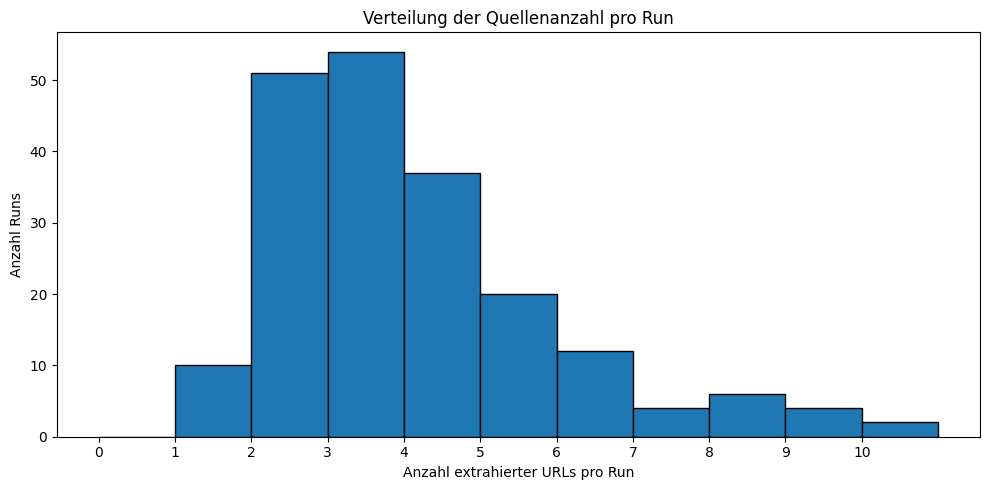

In [11]:
plt.figure(figsize=(10, 5))
plt.hist(sources_per_run["n_sources"], bins=range(0, int(sources_per_run["n_sources"].max()) + 2), edgecolor="black")
plt.title("Verteilung der Quellenanzahl pro Run")
plt.xlabel("Anzahl extrahierter URLs pro Run")
plt.ylabel("Anzahl Runs")
plt.xticks(range(0, int(sources_per_run["n_sources"].max()) + 1))
plt.tight_layout()
plt.show()

In [12]:
avg_sources_by_prompt = (
    sources_per_run.groupby(["prompt_id", "category"])
    .agg(
        mean_sources=("n_sources", "mean"),
        median_sources=("n_sources", "median"),
        min_sources=("n_sources", "min"),
        max_sources=("n_sources", "max"),
    )
    .reset_index()
)

avg_sources_by_prompt

,prompt_id,category,mean_sources,median_sources,min_sources,max_sources
0,P01,Faktische Frage,7.10,8.0,5,10
1,P02,Faktische Frage,2.25,2.0,2,3
2,P03,Faktische Frage,1.65,2.0,1,3
3,P04,Faktische Frage,2.40,2.0,2,3
4,P05,Prozedurale Frage,3.80,4.0,2,5
5,P06,Prozedurale Frage,3.15,3.0,2,5
6,P07,Prozedurale Frage,2.55,2.0,1,5
7,P08,Aktuelles Thema,3.50,3.5,3,4
8,P09,Aktuelles Thema,4.45,4.5,3,6
9,P10,Aktuelles Thema,5.45,5.5,4,8


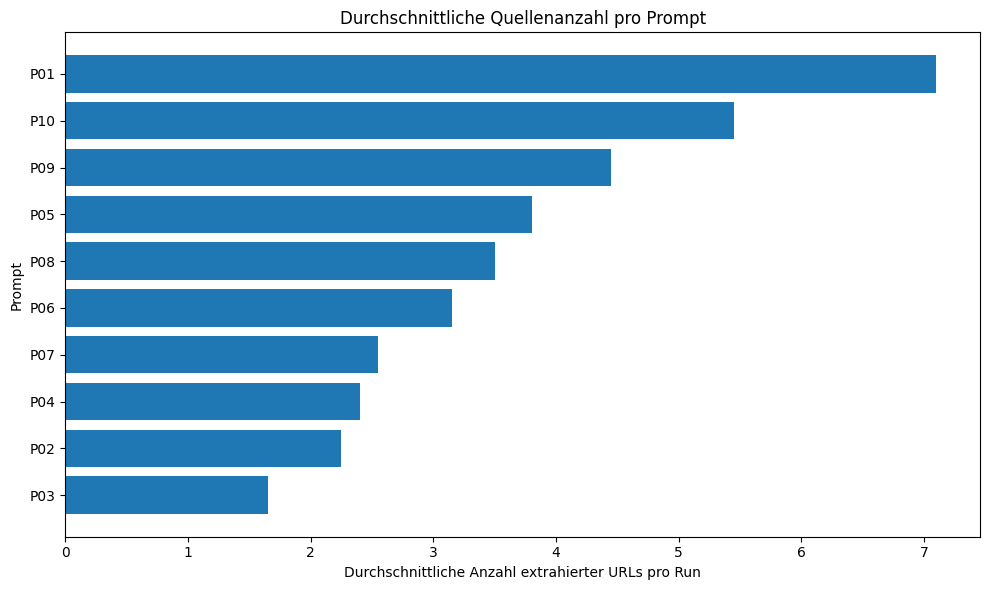

In [13]:
plot_df = avg_sources_by_prompt.sort_values("mean_sources", ascending=True)

plt.figure(figsize=(10, 6))
plt.barh(plot_df["prompt_id"], plot_df["mean_sources"])
plt.title("Durchschnittliche Quellenanzahl pro Prompt")
plt.xlabel("Durchschnittliche Anzahl extrahierter URLs pro Run")
plt.ylabel("Prompt")
plt.tight_layout()
plt.show()

## 4. Häufigste Domains und URLs

In [14]:
top_domains = (
    sources.groupby("domain")
    .agg(
        occurrences=("domain", "size"),
        prompts=("prompt_id", "nunique"),
        runs=("run_id", "nunique"),
    )
    .reset_index()
    .sort_values(["occurrences", "prompts"], ascending=False)
)

top_domains.head(20)

,domain,occurrences,prompts,runs
2,arbeitsagentur.de,64,1,20
60,service.berlin.de,50,1,20
42,ipcc.ch,37,1,20
62,statistik-berlin-brandenburg.de,31,1,20
66,tagesschau.de,29,1,20
11,bundesnetzagentur.de,24,2,24
77,verbraucherzentrale.de,24,1,20
23,climate.nasa.gov,23,1,20
13,bundesregierung.de,21,2,14
34,gesetze-im-internet.de,21,2,19


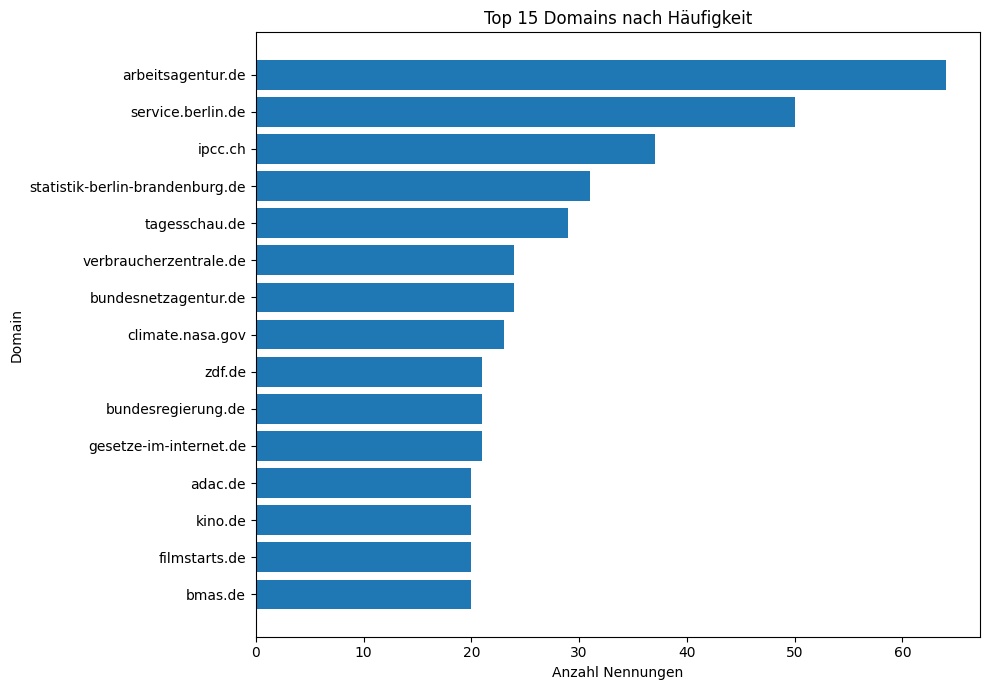

In [15]:
top_n = 15
plot_df = top_domains.head(top_n).sort_values("occurrences", ascending=True)

plt.figure(figsize=(10, 7))
plt.barh(plot_df["domain"], plot_df["occurrences"])
plt.title(f"Top {top_n} Domains nach Häufigkeit")
plt.xlabel("Anzahl Nennungen")
plt.ylabel("Domain")
plt.tight_layout()
plt.show()

In [16]:
top_urls = (
    sources.groupby(["url", "domain"])
    .agg(
        occurrences=("url", "size"),
        prompts=("prompt_id", "nunique"),
        runs=("run_id", "nunique"),
    )
    .reset_index()
    .sort_values(["occurrences", "prompts"], ascending=False)
)

top_urls.head(20)

,url,domain,occurrences,prompts,runs
20,https://service.berlin.de/dienstleistung/120686/,service.berlin.de,20,1,20
87,https://www.bmas.de/DE/Arbeit/Arbeitsrecht/Mindestlohn/mindestlohn.html,bmas.de,20,1,20
187,https://www.kino.de/kinoprogramm/,kino.de,19,1,19
4,https://climate.nasa.gov/,climate.nasa.gov,18,1,18
135,https://www.clever-tanken.de/,clever-tanken.de,15,1,15
179,https://www.ipcc.ch/report/ar6/syr/,ipcc.ch,14,1,14
190,https://www.mehr-tanken.de/,mehr-tanken.de,14,1,14
165,https://www.gesetze-im-internet.de/tkg_2021/__56.html,gesetze-im-internet.de,12,1,12
25,https://service.berlin.de/standorte/buergeraemter/,service.berlin.de,10,1,10
99,https://www.bundesnetzagentur.de/DE/Vportal/TK/Abrechnung/Vertrag/start.html,bundesnetzagentur.de,10,1,10


## 5. Quellen nach Kategorie

In [17]:
category_overview = (
    sources.groupby("category")
    .agg(
        source_rows=("url", "size"),
        runs_with_sources=("run_id", "nunique"),
        unique_urls=("url", "nunique"),
        unique_domains=("domain", "nunique"),
    )
    .reset_index()
)

category_overview["sources_per_run"] = category_overview["source_rows"] / category_overview["runs_with_sources"]
category_overview

,category,source_rows,runs_with_sources,unique_urls,unique_domains,sources_per_run
0,Aktuelles Thema,268,60,146,38,4.466667
1,Faktische Frage,268,80,132,37,3.350000
2,Prozedurale Frage,190,60,88,14,3.166667


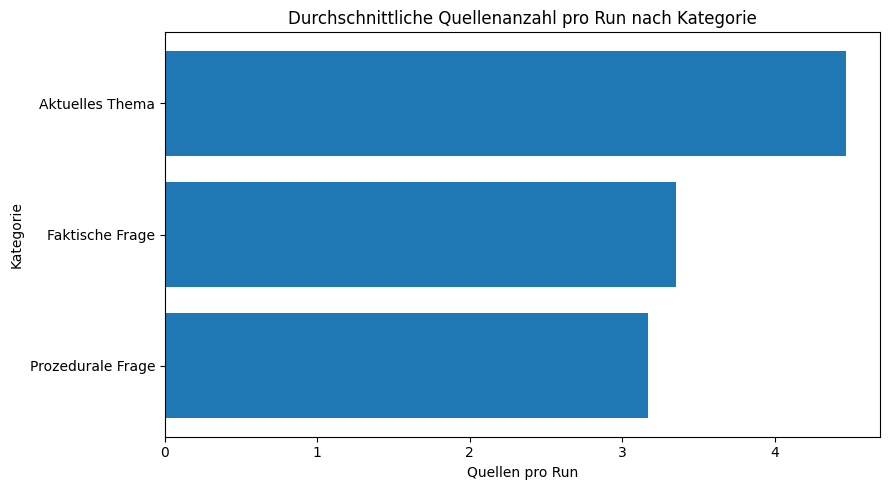

In [18]:
plot_df = category_overview.sort_values("sources_per_run", ascending=True)

plt.figure(figsize=(9, 5))
plt.barh(plot_df["category"], plot_df["sources_per_run"])
plt.title("Durchschnittliche Quellenanzahl pro Run nach Kategorie")
plt.xlabel("Quellen pro Run")
plt.ylabel("Kategorie")
plt.tight_layout()
plt.show()

## 6. Erste einfache Stabilitätsmaße

Für den Überblick nutzen wir zunächst zwei einfache Maße:

1. **URL-Wiederholungsrate pro Prompt**: Anteil der Run-Paare, in denen sich mindestens eine URL überschneidet.
2. **Durchschnittliche Jaccard-Ähnlichkeit pro Prompt**: Paarweise Überschneidung der URL-Mengen je Run.

Jaccard: 1 bedeutet identische URL-Mengen, 0 bedeutet keine Überschneidung.

In [19]:
from itertools import combinations

def jaccard(a, b):
    a = set(a)
    b = set(b)
    if not a and not b:
        return 1.0
    if not a or not b:
        return 0.0
    return len(a & b) / len(a | b)

stability_rows = []

# Wenn raw vorhanden ist, werden auch Runs ohne Quellen berücksichtigt.
if not raw.empty:
    run_base = raw[["prompt_id", "category", "run_id"]].drop_duplicates()
else:
    run_base = sources[["prompt_id", "category", "run_id"]].drop_duplicates()

for (prompt_id, category), group in run_base.groupby(["prompt_id", "category"]):
    run_ids = sorted(group["run_id"].unique())
    url_sets = {}
    domain_sets = {}
    for run_id in run_ids:
        subset = sources[(sources["prompt_id"] == prompt_id) & (sources["run_id"] == run_id)]
        url_sets[run_id] = set(subset["url"])
        domain_sets[run_id] = set(subset["domain"])

    url_jaccards = []
    domain_jaccards = []
    url_overlap_any = []
    domain_overlap_any = []

    for r1, r2 in combinations(run_ids, 2):
        uj = jaccard(url_sets[r1], url_sets[r2])
        dj = jaccard(domain_sets[r1], domain_sets[r2])
        url_jaccards.append(uj)
        domain_jaccards.append(dj)
        url_overlap_any.append(int(len(url_sets[r1] & url_sets[r2]) > 0))
        domain_overlap_any.append(int(len(domain_sets[r1] & domain_sets[r2]) > 0))

    stability_rows.append({
        "prompt_id": prompt_id,
        "category": category,
        "n_runs": len(run_ids),
        "mean_url_jaccard": np.mean(url_jaccards) if url_jaccards else np.nan,
        "mean_domain_jaccard": np.mean(domain_jaccards) if domain_jaccards else np.nan,
        "url_pair_overlap_rate": np.mean(url_overlap_any) if url_overlap_any else np.nan,
        "domain_pair_overlap_rate": np.mean(domain_overlap_any) if domain_overlap_any else np.nan,
    })

stability = pd.DataFrame(stability_rows).sort_values("mean_url_jaccard", ascending=False)
stability

,prompt_id,category,n_runs,mean_url_jaccard,mean_domain_jaccard,url_pair_overlap_rate,domain_pair_overlap_rate
6,P07,Prozedurale Frage,20,0.433434,0.950000,1.000000,1.000000
1,P02,Faktische Frage,20,0.301316,0.442018,1.000000,1.000000
7,P08,Aktuelles Thema,20,0.260702,0.559123,0.721053,1.000000
8,P09,Aktuelles Thema,20,0.193993,0.509129,0.926316,1.000000
0,P01,Faktische Frage,20,0.186607,0.357611,0.947368,1.000000
5,P06,Prozedurale Frage,20,0.125347,0.811404,0.531579,1.000000
3,P04,Faktische Frage,20,0.097105,0.581930,0.305263,0.968421
4,P05,Prozedurale Frage,20,0.056876,0.572105,0.342105,1.000000
9,P10,Aktuelles Thema,20,0.012673,0.571021,0.094737,1.000000
2,P03,Faktische Frage,20,0.010526,0.901754,0.031579,1.000000


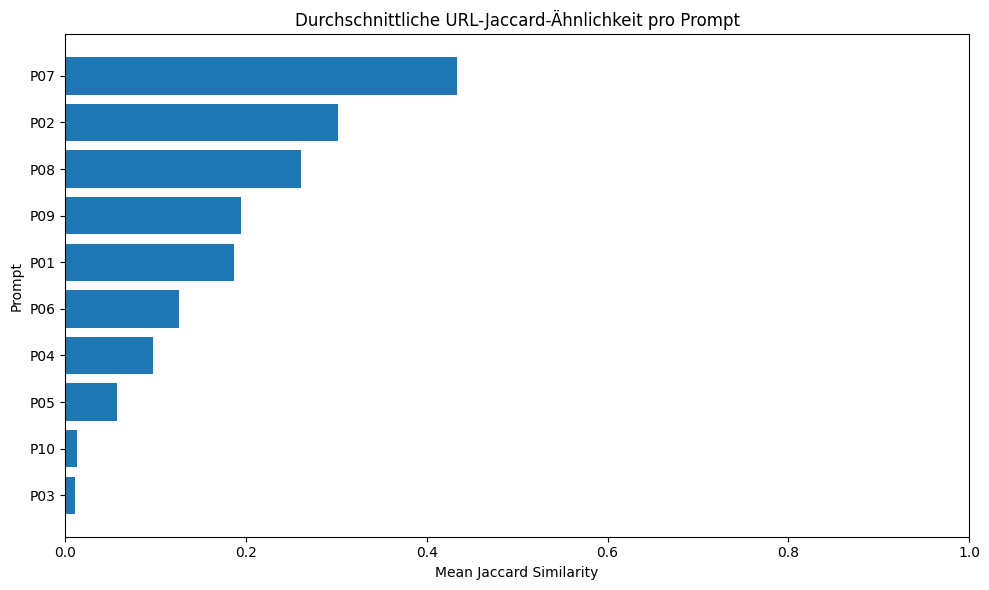

In [20]:
plot_df = stability.sort_values("mean_url_jaccard", ascending=True)

plt.figure(figsize=(10, 6))
plt.barh(plot_df["prompt_id"], plot_df["mean_url_jaccard"])
plt.title("Durchschnittliche URL-Jaccard-Ähnlichkeit pro Prompt")
plt.xlabel("Mean Jaccard Similarity")
plt.ylabel("Prompt")
plt.xlim(0, 1)
plt.tight_layout()
plt.show()

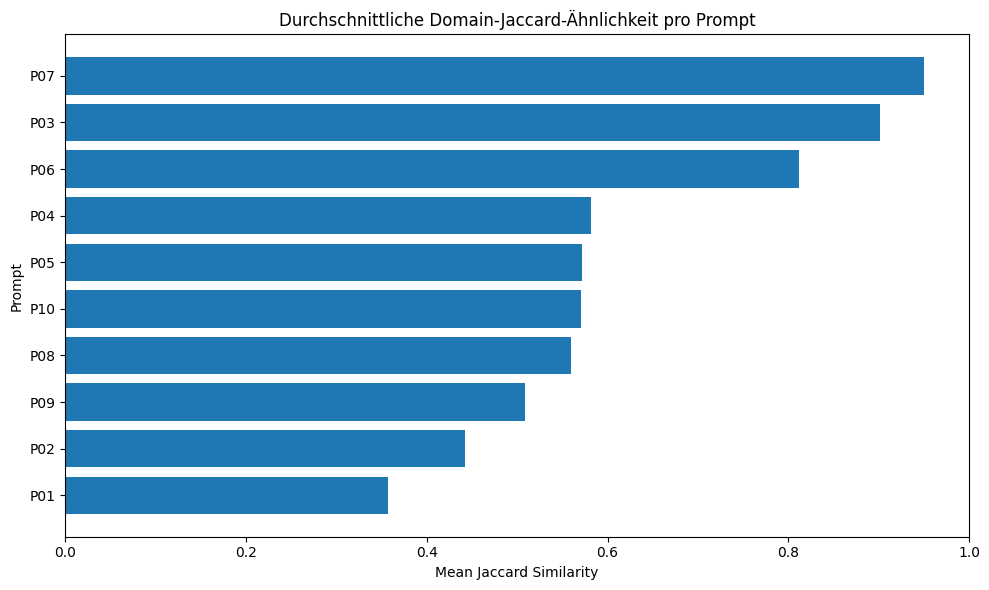

In [21]:
plot_df = stability.sort_values("mean_domain_jaccard", ascending=True)

plt.figure(figsize=(10, 6))
plt.barh(plot_df["prompt_id"], plot_df["mean_domain_jaccard"])
plt.title("Durchschnittliche Domain-Jaccard-Ähnlichkeit pro Prompt")
plt.xlabel("Mean Jaccard Similarity")
plt.ylabel("Prompt")
plt.xlim(0, 1)
plt.tight_layout()
plt.show()

## 7. Quellenhäufigkeit innerhalb einzelner Prompts

Diese Tabelle zeigt, welche Domains innerhalb eines Prompts über die Wiederholungen hinweg besonders häufig genannt wurden.

In [22]:
prompt_domain_freq = (
    sources.groupby(["prompt_id", "category", "domain"])
    .agg(
        occurrences=("domain", "size"),
        runs=("run_id", "nunique"),
    )
    .reset_index()
)

# Anteil der Runs, in denen die Domain mindestens einmal vorkam
runs_per_prompt = run_base.groupby("prompt_id")["run_id"].nunique().rename("total_runs").reset_index()
prompt_domain_freq = prompt_domain_freq.merge(runs_per_prompt, on="prompt_id", how="left")
prompt_domain_freq["run_coverage"] = prompt_domain_freq["runs"] / prompt_domain_freq["total_runs"]

prompt_domain_freq.sort_values(["prompt_id", "run_coverage", "occurrences"], ascending=[True, False, False]).head(50)

,prompt_id,category,domain,occurrences,runs,total_runs,run_coverage
9,P01,Faktische Frage,ipcc.ch,37,20,20,1.00
3,P01,Faktische Frage,climate.nasa.gov,23,20,20,1.00
4,P01,Faktische Frage,deutsches-klima-konsortium.de,10,10,20,0.50
6,P01,Faktische Frage,dwd.de,9,9,20,0.45
1,P01,Faktische Frage,climate.copernicus.eu,8,8,20,0.40
0,P01,Faktische Frage,carbonbrief.org,6,6,20,0.30
10,P01,Faktische Frage,klimafakten.de,6,6,20,0.30
16,P01,Faktische Frage,umweltbundesamt.de,6,6,20,0.30
12,P01,Faktische Frage,pik-potsdam.de,6,5,20,0.25
13,P01,Faktische Frage,public.wmo.int,5,5,20,0.25


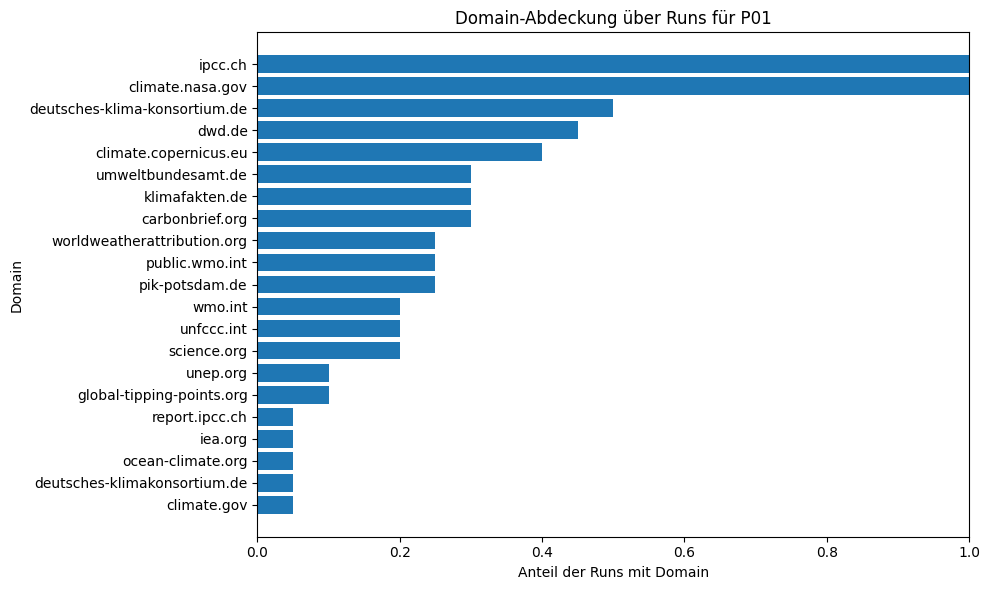

In [23]:
# Optional: Top-Domains für einen einzelnen Prompt anzeigen
PROMPT_TO_INSPECT = "P01"

df_prompt = prompt_domain_freq[prompt_domain_freq["prompt_id"] == PROMPT_TO_INSPECT].sort_values("run_coverage", ascending=True)

plt.figure(figsize=(10, 6))
plt.barh(df_prompt["domain"], df_prompt["run_coverage"])
plt.title(f"Domain-Abdeckung über Runs für {PROMPT_TO_INSPECT}")
plt.xlabel("Anteil der Runs mit Domain")
plt.ylabel("Domain")
plt.xlim(0, 1)
plt.tight_layout()
plt.show()

## 8. Zwischenergebnisse exportieren

In [24]:
OUTPUT_DIR = Path("data/analysis")
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

summary.to_csv(OUTPUT_DIR / "summary_overview.csv", index=False)
prompt_overview.to_csv(OUTPUT_DIR / "prompt_overview.csv", index=False)
sources_per_run.to_csv(OUTPUT_DIR / "sources_per_run.csv", index=False)
top_domains.to_csv(OUTPUT_DIR / "top_domains.csv", index=False)
top_urls.to_csv(OUTPUT_DIR / "top_urls.csv", index=False)
stability.to_csv(OUTPUT_DIR / "stability_overview.csv", index=False)
prompt_domain_freq.to_csv(OUTPUT_DIR / "prompt_domain_frequency.csv", index=False)

print("Exportiert nach:", OUTPUT_DIR.resolve())

Exportiert nach: C:\Users\lenaf\vscProjects\llm-quellenkonsistenz\notebooks\data\analysis


## Nächster Analyseschritt

Wenn dieser Überblick plausibel aussieht, wäre der nächste Schritt eine systematischere Konsistenzanalyse:

- Jaccard-Verteilung aller Run-Paare pro Prompt
- Vergleich URL-Stabilität vs. Domain-Stabilität
- Vergleich nach Prompt-Kategorie
- Identifikation stabiler Quellenkerne je Prompt
- Behandlung von Runs ohne Quellen
- kurze qualitative Prüfung, ob die extrahierten URLs wirklich im Antworttext als Quellen gemeint waren

In [25]:
# Übersicht: nur die 10 Prompts — welche Domains wurden innerhalb der Runs genannt (aggregiert), Häufigkeit auf 20
from pathlib import Path
import pandas as pd
import numpy as np
# Wähle die 10 Prompts (falls vorhanden aus prompt_overview, sonst aus sources)
if 'prompt_overview' in globals():
    prompts = list(prompt_overview['prompt_id'].unique())[:10]
else:
    prompts = sorted(sources['prompt_id'].unique())[:10]
# Sicherstellen, dass run_base existiert
if 'run_base' not in globals():
    if not raw.empty:
        run_base = raw[[ 'prompt_id','category','run_id']].drop_duplicates()
    else:
        run_base = sources[[ 'prompt_id','category','run_id']].drop_duplicates()
rows = []
for pid in prompts:
    total_runs = run_base[run_base['prompt_id']==pid]['run_id'].nunique()
    dfp = sources[sources['prompt_id']==pid]
    agg = dfp.groupby('domain').agg(runs=('run_id','nunique')).reset_index()
    agg['freq_of_20'] = agg.apply(lambda r: round(r['runs']/total_runs*20,2) if total_runs>0 else np.nan, axis=1)
    entries = agg.sort_values('runs', ascending=False).apply(lambda r: f"{r['domain']} ({r['freq_of_20'] if not pd.isna(r['freq_of_20']) else 'NA'})", axis=1).tolist()
    rows.append({'prompt_id': pid, 'domains': '; '.join(entries)})
summary = pd.DataFrame(rows)
pd.set_option('display.max_colwidth', 1000)
display(summary)
print('Prompts angezeigt:', len(summary))

,prompt_id,domains
0,P01,climate.nasa.gov (20.0); ipcc.ch (20.0); deutsches-klima-konsortium.de (10.0); dwd.de (9.0); climate.copernicus.eu (8.0); klimafakten.de (6.0); carbonbrief.org (6.0); umweltbundesamt.de (6.0); public.wmo.int (5.0); pik-potsdam.de (5.0); worldweatherattribution.org (5.0); wmo.int (4.0); science.org (4.0); unfccc.int (4.0); unep.org (2.0); global-tipping-points.org (2.0); climate.gov (1.0); ocean-climate.org (1.0); iea.org (1.0); deutsches-klimakonsortium.de (1.0); report.ipcc.ch (1.0)
1,P02,bmas.de (20.0); zoll.de (9.0); bgbl.de (5.0); mindestlohn-kommission.de (4.0); bundesregierung.de (3.0); gesetze-im-internet.de (3.0); recht.bund.de (1.0)
2,P03,statistik-berlin-brandenburg.de (20.0); berlin.de (1.0); statistikportal.de (1.0)
3,P04,stw.berlin (18.0); vbb.de (17.0); berlin.de (5.0); bvg.de (3.0); fu-berlin.de (1.0); studierendenwerk-berlin.de (1.0); hu-berlin.de (1.0)
4,P05,arbeitsagentur.de (20.0); web.arbeitsagentur.de (3.0); con.arbeitsagentur.de (2.0); bmfsfj.de (2.0); familienportal.de (2.0); bzst.de (1.0); elster.de (1.0); kindergeld-antrag.arbeitsagentur.de (1.0)
5,P06,verbraucherzentrale.de (20.0); bundesnetzagentur.de (19.0); gesetze-im-internet.de (16.0); aboalarm.de (2.0)
6,P07,service.berlin.de (20.0); berlin.de (1.0)
7,P08,adac.de (20.0); mehr-tanken.de (17.0); clever-tanken.de (16.0); bundesnetzagentur.de (5.0); bundeskartellamt.de (3.0); tankerkoenig.de (2.0); benzinpreis-blitz.de (1.0); guenstiger-tanken.de (1.0); de.statista.com (1.0); tanken.de (1.0); tanken.t-online.de (1.0); tankstellen-preise.de (1.0); tankstellen.bmwk.de (1.0)
8,P09,filmstarts.de (20.0); kino.de (20.0); uci-kinowelt.de (12.0); moviepilot.de (10.0); cineplex.de (8.0); cinemaxx.de (8.0); cinestar.de (4.0); google.de (1.0); insidekino.de (1.0); kino-zeit.de (1.0); metacritic.com (1.0); kinozeit.de (1.0); programmkino.de (1.0); rottentomatoes.com (1.0)
9,P10,tagesschau.de (20.0); spiegel.de (17.0); zdf.de (16.0); zeit.de (13.0); bundesregierung.de (11.0); handelsblatt.com (4.0); faz.net (2.0); bundespraesident.de (1.0); bundeskanzler.de (1.0); bmi.bund.de (1.0); wahlrecht.de (1.0)


Prompts angezeigt: 10
